# `inspect_moc.ipynb`

Tools for inspecting randoms, catalogs and MOC selection; as well as generating our own MOCs.

In [1]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table

In [2]:
desi = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_SGC_clustering.dat.fits'
    )
desi = desi[1].read(columns=['RA', 'DEC'])
coords_desi = SkyCoord(desi['RA'], desi['DEC'], unit='deg', frame='icrs')

hsc = fio.FITS(
    '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
hsc = hsc[1].read(columns=['ra', 'dec'])
coords_hsc = SkyCoord(hsc['ra'], hsc['dec'], unit='deg', frame='icrs')

moc_list = sorted(
        list(glob.glob(
    f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc*.fits'
    )))
print(moc_list)

['/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits', '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits', '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits', '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits']


In [3]:
list_hsc_randoms = [
    f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr{i}.fits'
    for i in range(0, 10)
]
ra, dec = [], []
for f in list_hsc_randoms:
    print(f)
    hsc_randoms = fio.FITS(f)
    hsc_randoms = hsc_randoms[1].read(columns=['ra', 'dec'])
    ra.extend(hsc_randoms['ra'][0::4])
    dec.extend(hsc_randoms['dec'][0::4])

coords_hsc_randoms = SkyCoord(
    np.array(ra) * u.deg, 
    np.array(dec) * u.deg, 
    frame='icrs'
    )

/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr0.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr1.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr2.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr3.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr4.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr5.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr6.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr7.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr8.fits
/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/randoms/edge_sc_cr_hscr9.fits


Computing coords
Coords computed in 1.38 seconds
Number of DESI targets in MOC: 136901
Number of HSC targets in MOC: 34407034
Number of DESI targets: 2753110
Percentage of DESI targets in MOC: 4.97%
Number of HSC randoms: 52399603
DESI targets
HSC targets


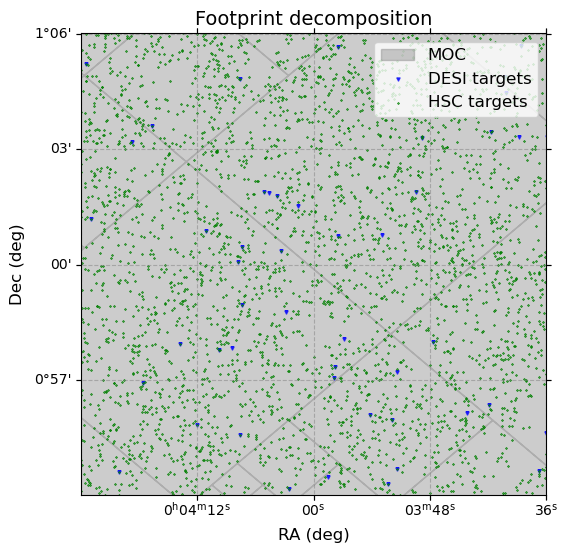

In [49]:
fig = plt.figure(figsize=(6, 6))

with MOCWCS(
    fig,
    fov= 0.2 * u.deg, #0.2 * u.deg, #180 * u.deg,
    center=SkyCoord(1, 1, unit='deg', frame='icrs'),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    projection="AIT"
    ) as wcs: 
    wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

tc = time.time()
print('Computing coords')
lon_hsc = coords_hsc.ra.wrap_at(180 * u.deg).degree
lat_hsc = coords_hsc.dec.degree

lon_desi = coords_desi.ra.wrap_at(180 * u.deg).degree
lat_desi = coords_desi.dec.degree
print(f'Coords computed in {time.time() - tc:.2f} seconds')

desi_in_moc_n = np.zeros(len(desi), dtype=bool)
hsc_in_moc_n = np.zeros(len(hsc), dtype=bool)
for i, mocf in enumerate(moc_list):
    moc = MOC.from_fits(mocf)
    hsc_in_moc_n |= moc.contains_skycoords(coords_hsc)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    moc.fill(
        ax=ax, 
        wcs=wcs, 
        alpha=0.4, 
        fill=True, 
        label='MOC', #f'{i} : {str(Path(mocf).stem)}', 
        color='gray'#plt.get_cmap('plasma')(i / len(moc_list))
        )
    moc.border(ax=ax, wcs=wcs, alpha=0.2, color="black")

desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree
hsc_in_moc = hsc[np.flatnonzero(hsc_in_moc_n)]
coords_hsc_in_moc = SkyCoord(hsc_in_moc['ra'], hsc_in_moc['dec'], unit='deg', frame='icrs')
lon_hsc_in_moc, lat_hsc_in_moc = coords_hsc_in_moc.ra.wrap_at(180 * u.deg).degree, coords_hsc_in_moc.dec.degree
print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of HSC targets in MOC: {len(hsc)}')
print(f'Number of DESI targets: {len(desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(desi) * 100:.2f}%')
print(f'Number of HSC randoms: {len(hsc_randoms)}')

print('DESI targets')
ax.scatter(
    lon_desi_in_moc,
    lat_desi_in_moc, 
    transform=tr,
    marker='v',
    s=5,
    color='blue', 
    alpha=0.7,
    label='DESI targets'
    )

print('HSC targets')
ax.scatter(
    lon_hsc_in_moc, 
    lat_hsc_in_moc,
    transform=tr,
    s=1, 
    marker='x',
    color='green', 
    alpha=0.7,
    label='HSC targets'
    )

#print('DESI targets in MOC')
#ax.scatter(
#    lon_desi_in_moc, 
#    lat_desi_in_moc,
#    transform=tr,
#    marker='^',
#    s=1,
#    color='black', 
#    alpha=1,
#    label='DESI targets'
#    )

ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('Footprint decomposition', fontsize=14)

capdict = {
    0 : 'NGC',
    1 : 'SGC',
    2 : 'SGC',
    3 : 'NGC',
}

In [28]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=4 * u.deg,
           center=SkyCoord(34, -3, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)
mocf = moc_list[0]
tr = ax.get_transform('world')
print('Loading MOC:', mocf)
moc = MOC.from_fits(mocf)

tc = time.time()
desi_in_moc_n = np.zeros(len(desi), dtype=bool)
desi_in_moc_n |= moc.contains_skycoords(coords_desi)
desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')

lon_desi = coords_desi.ra.wrap_at(180 * u.deg).degree
lat_desi = coords_desi.dec.degree

#lon_hsc_randoms = coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree
#lat_hsc_randoms = coords_hsc_randoms.dec.degree
print(f'Got coords in {time.time() - tc:.2f} seconds')

ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=1,
    color='red', 
    alpha=0.8,
    label='DESI targets'
    )
print('DESI randoms targets')

moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

Loading MOC: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits
Got coords in 0.30 seconds
DESI randoms targets
Error in callback <function _draw_all_if_interactive at 0x7f05ea034cc0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (2, 0)

ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (2, 0)

<Figure size 1200x600 with 1 Axes>

In [ ]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=30 * u.deg,
           center=SkyCoord(179, 0, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

tc = time.time()
print('Computing coords')
lon_hsc = coords_hsc.ra.wrap_at(180 * u.deg).degree
lat_hsc = coords_hsc.dec.degree

lon_desi = coords_desi.ra.wrap_at(180 * u.deg).degree
lat_desi = coords_desi.dec.degree

lon_hsc_randoms = coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree
lat_hsc_randoms = coords_hsc_randoms.dec.degree
print(f'Coords computed in {time.time() - tc:.2f} seconds')

desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
    moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree

print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of HSC targets in MOC: {len(hsc)}')
print(f'Number of DESI targets: {len(desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(desi) * 100:.2f}%')
print(f'Number of HSC randoms: {len(hsc_randoms)}')

print('DESI targets')
ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=0.05,
    color='red', 
    alpha=1,
    label='DESI targets'
    )

print('HSC targets')
ax.scatter(
    lon_hsc, 
    lat_hsc,
    transform=tr,
    s=0.2, 
    marker='x',
    color='green', 
    alpha=0.7,
    label='HSC targets'
    )

print('DESI targets in MOC')
ax.scatter(
    lon_desi_in_moc, 
    lat_desi_in_moc,
    transform=tr,
    marker='^',
    s=1,
    color='black', 
    alpha=1,
    label='DESI targets in MOC'
    )

print('HSC randoms targets - hexbin')
# Replace the scatter plot with hexbin for HSC randoms
hb = ax.hexbin(
    coords_hsc_randoms.ra.wrap_at(180 * u.deg).degree,
    coords_hsc_randoms.dec.degree,
    transform=tr,
    gridsize=300,  # Adjust this value to control hexbin resolution
    cmap='plasma',  # Use a blue colormap
    alpha=0.7,
    mincnt=1,
    label='HSC randoms'
)
# Add a colorbar for the hexbin plot
cbar = plt.colorbar(hb, ax=ax, pad=0.01)
cbar.set_label('HSC randoms count')

ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('HSC-DESI targets on MOCs', fontsize=14)

In [ ]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=10 * u.deg,
           center=SkyCoord(179, 0, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

mocidx = 1
print(moc_list[mocidx])
moc = MOC.from_fits(moc_list[mocidx])
moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

In [ ]:
from desitarget.targetmask import desi_mask

desi_tgt = desi['DESI_TARGET']

is_bgs  = (desi_tgt & desi_mask.BGS_ANY != 0)   #- instead of 2**60
is_lrg  = (desi_tgt & desi_mask.LRG != 0)
is_elg  = (desi_tgt & desi_mask.ELG != 0)
is_qso  = (desi_tgt & desi_mask.QSO != 0)
is_mws  = (desi_tgt & desi_mask.MWS_ANY != 0)
is_scnd = (desi_tgt & desi_mask.SCND_ANY != 0)
masks = {
    'BGS': is_bgs,
    'LRG': is_lrg,
    'ELG': is_elg,
    'QSO': is_qso,
    #'MWS': is_mws,
    #'SCND': is_scnd
}


Generating our own randoms using the provided HSC flags

In [ ]:
all_coords_hsc_randoms = [[], []]
data_hsc_path = '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/'
for i in range(0, 10):
    print('Loading MOC:', i)
    hsc_randoms = fio.FITS(
        f'{data_hsc_path}randoms_bulk/hscr{i}.fits'
        )
    # object_id, ra, dec, isprimary, 
    # i_pixelflags_edge, i_pixelflags_bright_objectcenter, 
    # i_pixelflags_saturatedcenter, i_pixelflags_crcenter
    hsc_randoms = hsc_randoms[1].read(columns=[
        'ra', 'dec', 'isprimary', 'i_pixelflags_edge',
        #'i_pixelflags_bright_objectcenter',
        'i_pixelflags_saturatedcenter', 'i_pixelflags_crcenter'
        ])
    ra = hsc_randoms['ra'][0::3]
    dec = hsc_randoms['dec'][0::3]
    mask = hsc_randoms['isprimary']
    if i == 0:
        print(f'{mask.sum()/len(mask)*100:.2f}% of randoms are primary. {mask[0:5]} ...')
    for flag in [ 
        'i_pixelflags_edge', 
        #'i_pixelflags_bright_objectcenter', 
        'i_pixelflags_saturatedcenter', 
        'i_pixelflags_crcenter'
        ]:
        submask = ~hsc_randoms[flag]
        if i == 0:
            print(f'Flag {flag}: {submask.sum()/len(submask)*100:.2f}%')
        mask &= submask

    save_hsc_randoms = hsc_randoms[mask]
    output_filename = f'{data_hsc_path}/randoms/edge_sc_cr_hscr{i}.fits'
    fio.write(output_filename, save_hsc_randoms, clobber=True)
    print(f'Wrote {output_filename}')
    if i == 0:
        print(f'{mask.sum()/len(mask)*100:.2f}% of randoms are primary and not flagged. {mask[0:5]} ...')
    all_coords_hsc_randoms[0].extend(ra)
    all_coords_hsc_randoms[1].extend(dec)
    
coords_hsc_randoms = SkyCoord(
    np.array(all_coords_hsc_randoms[0]) * u.deg, 
    np.array(all_coords_hsc_randoms[1]) * u.deg, 
    frame='icrs'
    )